In [1]:
from matplotlib import rcParams
from matplotlib.style import use
from os import environ
from cycler import cycler
from math import log10, floor

from numpy import log, interp
from numpy.ma import array as marray

# expose subplots constructor
from matplotlib.pyplot import figure, subplots, subplot_mosaic, get_cmap, close

# expose useful matplotlib constructs
from matplotlib.lines import Line2D

# expose handy matplotlib functions useful for colorbars
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm, TwoSlopeNorm
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

# for labelling plots
from string import ascii_lowercase
idx_to_alpha = dict(enumerate(ascii_lowercase))

from os import environ

# new default settings
params = {
    "font.family": "sans-serif",
    "text.usetex": True,
    "mathtext.fontset": "cm",
    "text.latex.preamble": "\n".join([
            r"\usepackage{amsmath}", r"\usepackage{lmodern}",
            r"\usepackage{siunitx}",
            r"\usepackage{physics}", r"\usepackage{bm}",
            r"\usepackage{nicefrac}", r"\usepackage{amssymb}"
        ]),
    "figure.figsize": [4, 4],
    "lines.linewidth": 1.5,
    "lines.markersize": 4.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "axes.formatter.limits": [-3, 3],
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "hist.bins": "auto",
    "errorbar.capsize": 2.0,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "axes.prop_cycle": cycler(
        color=['#4D4D4D', '#5DA4DA', '#FAA43A', '#60BD68',
               '#F17CB0', '#B2912F', '#B276B2', '#DECF3F',
               '#F15854']
        ),
    "patch.facecolor": '348ABD',
    "patch.edgecolor": '110d1b',
    "patch.antialiased": True,
    "patch.linewidth": 0.5,
    "axes.xmargin": 0.0,
    "figure.dpi": 100,
    "savefig.dpi": "figure",
    }

# get the default style
option = environ["PLT_STYLE"]
use([option, "seaborn-v0_8-paper"])

# update parameters
rcParams.update(params)

# common plot settings
err_kwargs = dict(capsize=2.0, elinewidth=1.5, markeredgewidth=1.5, ms=4.0)
ref_kwargs = dict(ls=":", color="darkgray", zorder=1)

# notate with regular scientific notation
def sci_notation(num, decimal_digits=1, precision=None, exponent=None):
    """
    Returns a string representation of the scientific
    notation of the given number formatted for use with
    LaTeX or Mathtext, with specified number of significant
    decimal digits and precision (number of decimal digits
    to show). The exponent to be used can also be specified
    explicitly.
    """
    if exponent is None:
        exponent = int(floor(log10(abs(num))))
    coeff = round(num / float(10**exponent), decimal_digits)
    if precision is None:
        precision = decimal_digits

    if (abs(coeff-1.0) > 1e-6):
        return r"{0:.{2}f}\cdot 10^{{{1:d}}}".format(coeff, exponent, precision)
    else:
        return "10^{{{0:d}}}".format(exponent)


class MidPointNorm(LogNorm):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        LogNorm.__init__(self, vmin=vmin, vmax=vmax, clip=clip)
        self.midpoint=midpoint
        def __call__(self, value, clip=None):
            result, is_scalar = self.process_value(value)
            x, y = [log(self.vmin), log(self.midpoint), log(self.vmax)], [0, 0.5, 1]
            return marray(interp(log(value), x, y), mask=result.mask, copy=False)

from scipy.signal import welch

def get_power_spectrum(data, nbins=5e4, nin=50):

    segsize = round((data.size-1)/nin/2)*2

    fqs, pspec = welch(data, nbins, nperseg=segsize, noverlap=0, window="boxcar")
    pspec_sd = pspec/sqrt(nin)

    return (fqs, pspec, pspec_sd)

import numpy
import matplotlib
from matplotlib import pylab, mlab, pyplot
np = numpy
plt = pyplot

from IPython.display import display
from IPython.core.pylabtools import figsize, getfigs

from numpy import *
from numpy.linalg import *
from numpy.random import *
from numpy.fft import *

In [2]:
%matplotlib widget

In [3]:
from pandas import read_csv, read_excel, concat as pdconcat
from shapely.geometry import Point, Polygon
from geopandas import GeoDataFrame, read_file
from geodatasets import get_path, data

In [4]:
from scipy.interpolate import CubicSpline
from scipy.io import whosmat, loadmat

In [5]:
myvars = locals()

In [6]:
set_printoptions(linewidth=500, formatter=dict(float=lambda x: f"{x:.8e}"))

# Load data into workspace and perform computations

In [7]:
supply_df = read_csv("../data/gac_sol_1.0mw_supply-curve-aggregation.csv")

In [8]:
sorted_df = supply_df.sort_values(by=["capacity"])
sorted_sites_gid = sorted_df["sc_gid"].to_numpy()
sorted_df_reduced = sorted_df
sorted_df_reduced_gid = sorted_df_reduced["sc_gid"].to_numpy()
tot_red_sites = len(sorted_df_reduced)

In [9]:
capacity_df = read_csv("../data/gac_sol_1.0mw_capacity_profiles.csv")

In [10]:
stest = read_file("../data/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")

In [11]:
southeast = stest.loc[(stest["STATEFP"] == "01") | (stest["STATEFP"] == "12") | (stest["STATEFP"] == "13") | (stest["STATEFP"] == "45")]
ga = stest.loc[(stest["STATEFP"] == "13")]
sc = stest.loc[(stest["STATEFP"] == "45")]
ga_sc = pdconcat([ga, sc])
ga_counties = ga.loc[ga['NAME'].isin(["Chatham", "Bryan", "Liberty", "Effingham", "Evans", "Bulloch", "Screven"])]
sc_counties = sc.loc[sc['NAME'].isin(["Jasper", "Beaufort", "Hampton"])]
ga_sc_counties = pdconcat([ga_counties, sc_counties])

In [12]:
_base_data = read_excel("../data/excess_loadDemand_emissions_data.xlsx")
load_demand = _base_data["Grid_Energy_hrs (kWh)"].to_numpy().sum()/1e3
solar_demand = _base_data["DER_Solar1MW_Pwr (MW)"].to_numpy().reshape((365, 24)).T
hr_mat, day_mat = meshgrid(arange(1, 25), arange(1, 366), indexing="ij")

In [13]:
_data = load("../data/results/site_varied/800kWh_fullElectrification/processed_results_siteVariation.npz")
for key, val in _data.items():
    if isinstance(val, ndarray):
        print(key)
        myvars[key] = val.squeeze()

carbon_reduction_optimal
carbon_subtracted_optimal
tot_solar
tot_solar_curtailed_optimal
tot_batt_dchg_optimal
tot_batt_throughput_optimal
fractions_optimal
fractions_batt_charge_optimal
cycles_optimal


In [14]:
_data = load("../data/results/site_varied/800kWh_VMTElectrification/processed_results_siteVariation2.npz")
for key, val in _data.items():
    if isinstance(val, ndarray):
        print(key + "2")
        myvars[key + "2"] = val.squeeze()

carbon_reduction_optimal2
carbon_subtracted_optimal2
tot_solar2
tot_solar_curtailed_optimal2
tot_batt_dchg_optimal2
tot_batt_throughput_optimal2
fractions_optimal2
fractions_batt_charge_optimal2
cycles_optimal2


In [15]:
srtd_cap_df = capacity_df.loc[sorted_sites_gid]
srtd_cap_df_reduced = capacity_df.loc[sorted_df_reduced["sc_gid"].to_numpy()]
srtd_cap_df_reduced["carbon_reduction"] = carbon_reduction_optimal[sorted_df_reduced_gid, 1, 1]

In [16]:
df_solarCapEx = read_excel("../data/SolarCapEX.xlsx")
solar_capacity_data = df_solarCapEx["Capacity (MW)"].to_numpy()
solar_cap_cost_data = df_solarCapEx["Solar Capital Cost"].to_numpy()

cs = CubicSpline(solar_capacity_data, solar_cap_cost_data)

In [17]:
df_batteryCapEx = read_excel("../data/BatteryStorageCapEx.xlsx", sheet_name="35 GWh")
battery_capacity_data = df_batteryCapEx["Power (MW)"].to_numpy()
NMC_cap_cost_data = df_batteryCapEx["NMC"].to_numpy()
NCA_cap_cost_data = df_batteryCapEx["NCA"].to_numpy()
LFP_cap_cost_data = df_batteryCapEx["LFP"].to_numpy()

NMC_cs = CubicSpline(battery_capacity_data, NMC_cap_cost_data)
NCA_cs = CubicSpline(battery_capacity_data, NCA_cap_cost_data)
LFP_cs = CubicSpline(battery_capacity_data, LFP_cap_cost_data)

In [18]:
def compute_LCOPR(OCS, PV2GRID, PR, N, E0):
    
    numerator = OCS - PV2GRID*N*PR
    denominator = N*2*E0

    if E0 == 0.0:
        return 0.0
    else:
        return numerator/denominator

In [19]:
def compute_LCOS(OCS, E_rated, N_EOL):

    numerator = OCS
    denominator = N_EOL*E_rated

    return numerator/denominator

In [20]:
site_LCOPR_woReturns = zeros((tot_red_sites, 3))
site_LCOPR_wReturns = zeros((tot_red_sites, 3))

for i in range(tot_red_sites):
    for j in range(3):
        nameplate_solar_cap = sorted_df_reduced.iloc[i]["capacity"].item()
        site_LCOPR_woReturns[i, j] = compute_LCOPR(OCS=cs(nameplate_solar_cap),  
                                                   PV2GRID=tot_solar_curtailed_optimal[sorted_df_reduced_gid[i], j, 0], 
                                                   PR=0.0, 
                                                   N=30, 
                                                   E0=tot_solar[sorted_df_reduced_gid[i], j, 0], 
                                                   )
        site_LCOPR_wReturns[i, j] = compute_LCOPR(OCS=cs(nameplate_solar_cap),  
                                                  PV2GRID=tot_solar_curtailed_optimal[sorted_df_reduced_gid[i], j, 0], 
                                                  PR=48.0, 
                                                  N=30, 
                                                  E0=tot_solar[sorted_df_reduced_gid[i], j, 0], 
                                                  )

In [21]:
NMC_Ncycles = array([800, 2000, 2500])
NCA_Ncycles = array([500, 1400, 2000])
LFP_Ncycles = array([1800, 6000, 7000])

In [22]:
battery_sizes = linspace(0.0, 100.0, 100//10 + 1)
batt_LCOS = zeros((3, len(battery_sizes), 3))

rated_duration_h = 4.0

for i, batt_size in enumerate(battery_sizes):
    if i == 0:
        continue
        
    for j in range(3):
        
        batt_LCOS[0, i, j] = compute_LCOS(OCS=NMC_cs(batt_size/rated_duration_h), 
                                          E_rated=batt_size, 
                                          N_EOL=NMC_Ncycles[j])
        batt_LCOS[1, i, j] = compute_LCOS(OCS=NCA_cs(batt_size/rated_duration_h), 
                                          E_rated=batt_size,
                                          N_EOL=NCA_Ncycles[j])
        batt_LCOS[2, i, j] = compute_LCOS(OCS=LFP_cs(batt_size/rated_duration_h), 
                                          E_rated=batt_size,  
                                          N_EOL=LFP_Ncycles[j])

In [23]:
batt_LCOS.mean(axis=1) # chemistry down the rows, aging scenario across columns

array([[3.36158846e+02, 1.34463539e+02, 1.07570831e+02],
       [6.81107955e+02, 2.43252841e+02, 1.70276989e+02],
       [2.09698020e+02, 6.29094060e+01, 5.39223480e+01]])

Define TEC calculation

In [24]:
YrsOperation_noBatt = 30
GridElectricityPrice = 160

In [25]:
YrsOperation_NMC = NMC_Ncycles[None,None,None,:]/cycles_optimal[sorted_df_reduced_gid,None,:,1,None]
YrsOperation_NCA = NCA_Ncycles[None,None,None,:]/cycles_optimal[sorted_df_reduced_gid,None,:,1,None]
YrsOperation_LFP = LFP_Ncycles[None,None,None,:]/cycles_optimal[sorted_df_reduced_gid,None,:,1,None]

system_lifetime_NMC = maximum(YrsOperation_noBatt, minimum(15.0, YrsOperation_NMC))
system_lifetime_NCA = maximum(YrsOperation_noBatt, minimum(15.0, YrsOperation_NCA))
system_lifetime_LFP = maximum(YrsOperation_noBatt, minimum(15.0, YrsOperation_LFP))

In [26]:
NMC_100MWh_cost = batt_LCOS[0, -1, :] 
NCA_100MWh_cost = batt_LCOS[1, -1, :]
LFP_100MWh_cost = batt_LCOS[2, -1, :]

cost_no_batt = fractions_optimal[sorted_df_reduced_gid, :, 0, 0]*site_LCOPR_woReturns + fractions_optimal[sorted_df_reduced_gid, :, 0, 2]*GridElectricityPrice

cost_w_batt_NMC = (fractions_optimal[sorted_df_reduced_gid, None, :, 1, 0, None]*(site_LCOPR_woReturns[:,None,:,None]) 
                   + fractions_optimal[sorted_df_reduced_gid, None, :, 1, 1, None]*(fractions_batt_charge_optimal[sorted_df_reduced_gid, None, :, 1, 0, None]*site_LCOPR_woReturns[:,None,:,None] + fractions_batt_charge_optimal[sorted_df_reduced_gid, None, :, 1, 1, None]*GridElectricityPrice + NMC_100MWh_cost[None,None,None,:]) 
                   + fractions_optimal[sorted_df_reduced_gid, None, :, 1, 2, None]*GridElectricityPrice)
cost_w_batt_NCA = (fractions_optimal[sorted_df_reduced_gid, None, :, 1, 0, None]*(site_LCOPR_woReturns[:,None,:,None])
                   + fractions_optimal[sorted_df_reduced_gid, None, :, 1, 1, None]*(fractions_batt_charge_optimal[sorted_df_reduced_gid, None, :, 1, 0, None]*site_LCOPR_woReturns[:,None,:,None] + fractions_batt_charge_optimal[sorted_df_reduced_gid, None, :, 1, 1, None]*GridElectricityPrice + NCA_100MWh_cost[None,None,None,:]) 
                   + fractions_optimal[sorted_df_reduced_gid, None, :, 1, 2, None]*GridElectricityPrice)
cost_w_batt_LFP = (fractions_optimal[sorted_df_reduced_gid, None, :, 1, 0, None]*(site_LCOPR_woReturns[:,None,:,None])
                   + fractions_optimal[sorted_df_reduced_gid, None, :, 1, 1, None]*(fractions_batt_charge_optimal[sorted_df_reduced_gid, None, :, 1, 0, None]*site_LCOPR_woReturns[:,None,:,None] + fractions_batt_charge_optimal[sorted_df_reduced_gid, None, :, 1, 1, None]*GridElectricityPrice + LFP_100MWh_cost[None,None,None,:]) 
                   + fractions_optimal[sorted_df_reduced_gid, None, :, 1, 2, None]*GridElectricityPrice)

In [27]:
YrsOperation_NMC2 = NMC_Ncycles[None,None,None,:]/cycles_optimal2[sorted_df_reduced_gid,None,:,1,None]
YrsOperation_NCA2 = NCA_Ncycles[None,None,None,:]/cycles_optimal2[sorted_df_reduced_gid,None,:,1,None]
YrsOperation_LFP2 = LFP_Ncycles[None,None,None,:]/cycles_optimal2[sorted_df_reduced_gid,None,:,1,None]

system_lifetime_NMC2 = maximum(YrsOperation_noBatt, minimum(15.0, YrsOperation_NMC2))
system_lifetime_NCA2 = maximum(YrsOperation_noBatt, minimum(15.0, YrsOperation_NCA2))
system_lifetime_LFP2 = maximum(YrsOperation_noBatt, minimum(15.0, YrsOperation_LFP2))

In [28]:
NMC_100MWh_cost2 = batt_LCOS[0, -1, :]  
NCA_100MWh_cost2 = batt_LCOS[1, -1, :] 
LFP_100MWh_cost2 = batt_LCOS[2, -1, :] 

cost_no_batt2 = fractions_optimal2[sorted_df_reduced_gid, :, 0, 0]*site_LCOPR_woReturns + fractions_optimal2[sorted_df_reduced_gid, :, 0, 2]*GridElectricityPrice

cost_w_batt_NMC2 = (fractions_optimal2[sorted_df_reduced_gid, None, :, 1, 0, None]*(site_LCOPR_woReturns[:,None,:,None])
                   + fractions_optimal2[sorted_df_reduced_gid, None, :, 1, 1, None]*(fractions_batt_charge_optimal2[sorted_df_reduced_gid, None, :, 1, 0, None]*site_LCOPR_woReturns[:,None,:,None] + fractions_batt_charge_optimal2[sorted_df_reduced_gid, None, :, 1, 1, None]*GridElectricityPrice + NMC_100MWh_cost2[None,None,None,:]) 
                   + fractions_optimal2[sorted_df_reduced_gid, None, :, 1, 2, None]*GridElectricityPrice)
cost_w_batt_NCA2 = (fractions_optimal2[sorted_df_reduced_gid, None, :, 1, 0, None]*(site_LCOPR_woReturns[:,None,:,None])
                   + fractions_optimal2[sorted_df_reduced_gid, None, :, 1, 1, None]*(fractions_batt_charge_optimal2[sorted_df_reduced_gid, None, :, 1, 0, None]*site_LCOPR_woReturns[:,None,:,None] + fractions_batt_charge_optimal2[sorted_df_reduced_gid, None, :, 1, 1, None]*GridElectricityPrice + NCA_100MWh_cost2[None,None,None,:]) 
                   + fractions_optimal2[sorted_df_reduced_gid, None, :, 1, 2, None]*GridElectricityPrice)
cost_w_batt_LFP2 = (fractions_optimal2[sorted_df_reduced_gid, None, :, 1, 0, None]*(site_LCOPR_woReturns[:,None,:,None])
                   + fractions_optimal2[sorted_df_reduced_gid, None, :, 1, 1, None]*(fractions_batt_charge_optimal2[sorted_df_reduced_gid, None, :, 1, 0, None]*site_LCOPR_woReturns[:,None,:,None] + fractions_batt_charge_optimal2[sorted_df_reduced_gid, None, :, 1, 1, None]*GridElectricityPrice + LFP_100MWh_cost2[None,None,None,:]) 
                   + fractions_optimal2[sorted_df_reduced_gid, None, :, 1, 2, None]*GridElectricityPrice)

In [29]:
YrsOperation_fleet = 5*ones(system_lifetime_NMC.shape) 

OCC_PV = cs(sorted_df_reduced["capacity"].to_numpy())
OCC_b_NMC = NMC_cs(battery_sizes/4.0)
OCC_b_NCA = NCA_cs(battery_sizes/4.0)
OCC_b_LFP = LFP_cs(battery_sizes/4.0)

IC_utility_noBatt = OCC_PV
IC_utility_NMC = (system_lifetime_NMC/YrsOperation_noBatt)*OCC_PV[:,None,None,None] + (system_lifetime_NMC/YrsOperation_NMC)*OCC_b_NMC[None,:,None,None] # (sites) x (battery size) x (demand shift)
IC_utility_NCA = (system_lifetime_NCA/YrsOperation_noBatt)*OCC_PV[:,None,None,None] + (system_lifetime_NCA/YrsOperation_NCA)*OCC_b_NCA[None,:,None,None]
IC_utility_LFP = (system_lifetime_LFP/YrsOperation_noBatt)*OCC_PV[:,None,None,None] + (system_lifetime_LFP/YrsOperation_LFP)*OCC_b_LFP[None,:,None,None]

cost_no_batt2 = fractions_optimal2[sorted_df_reduced_gid, :, 0, 0]*site_LCOPR_woReturns + fractions_optimal2[sorted_df_reduced_gid, :, 0, 2]*GridElectricityPrice

TCO_utility_noBatt = (1.0 + 0.01763598*YrsOperation_fleet)*OCC_PV[:,None,None,None] - (IC_utility_noBatt[:,None,None,None] + 0.01763598*YrsOperation_fleet*OCC_PV[:,None,None,None])*(YrsOperation_fleet/YrsOperation_noBatt)
TCO_utility_wBatt_NMC = (
    (system_lifetime_NMC/YrsOperation_noBatt + 0.01763598*YrsOperation_fleet)*OCC_PV[:,None,None,None]
    + (system_lifetime_NMC/YrsOperation_NMC + 0.0043*YrsOperation_fleet)*OCC_b_NMC[None,:,None,None] 
    - (IC_utility_NMC + 0.01763598*YrsOperation_fleet*OCC_PV[:,None,None,None] + 0.0043*YrsOperation_fleet*OCC_b_NMC[None,:,None,None])*(YrsOperation_fleet/system_lifetime_NMC)
    )
TCO_utility_wBatt_NCA = (
    (system_lifetime_NCA/YrsOperation_noBatt + 0.01763598*YrsOperation_fleet)*OCC_PV[:,None,None,None]
    + (system_lifetime_NCA/YrsOperation_NCA + 0.0043*YrsOperation_fleet)*OCC_b_NCA[None,:,None,None] 
    - (IC_utility_NCA + 0.01763598*YrsOperation_fleet*OCC_PV[:,None,None,None] + 0.0043*YrsOperation_fleet*OCC_b_NCA[None,:,None,None])*(YrsOperation_fleet/system_lifetime_NCA)
    )
TCO_utility_wBatt_LFP = (
    (system_lifetime_LFP/YrsOperation_noBatt + 0.01763598*YrsOperation_fleet)*OCC_PV[:,None,None,None]
    + (system_lifetime_LFP/YrsOperation_LFP + 0.0043*YrsOperation_fleet)*OCC_b_LFP[None,:,None,None] 
    - (IC_utility_LFP + 0.01763598*YrsOperation_fleet*OCC_PV[:,None,None,None] + 0.0043*YrsOperation_fleet*OCC_b_LFP[None,:,None,None])*(YrsOperation_fleet/system_lifetime_LFP)
    )

TCO_utility_noBatt_perKgCO2 = TCO_utility_noBatt/(carbon_subtracted_optimal[sorted_df_reduced_gid, None, :, 0, None]*907.185*YrsOperation_noBatt)
TCO_utility_wBatt_NMC_perKgCO2 = TCO_utility_wBatt_NMC/(carbon_subtracted_optimal[sorted_df_reduced_gid, None, :, 1, None]*907.185*system_lifetime_NMC)
TCO_utility_wBatt_NCA_perKgCO2 = TCO_utility_wBatt_NCA/(carbon_subtracted_optimal[sorted_df_reduced_gid, None, :, 1, None]*907.185*system_lifetime_NCA)
TCO_utility_wBatt_LFP_perKgCO2 = TCO_utility_wBatt_LFP/(carbon_subtracted_optimal[sorted_df_reduced_gid, None, :, 1, None]*907.185*system_lifetime_LFP)

In [30]:
min_utility_sites = zeros((3, 4))
for i in range(3):
    min_utility_sites[i,:] = c_[TCO_utility_wBatt_NMC_perKgCO2[:,-1,1,i].argmin(), TCO_utility_wBatt_NCA_perKgCO2[:,-1,1,i].argmin(), TCO_utility_wBatt_LFP_perKgCO2[:,-1,1,i].argmin(), TCO_utility_noBatt_perKgCO2[:,-1,1,i].argmin()] 

In [31]:
min_utility_sites

array([[4.60000000e+01, 4.60000000e+01, 4.60000000e+01, 0.00000000e+00],
       [4.60000000e+01, 4.60000000e+01, 3.90000000e+01, 0.00000000e+00],
       [4.60000000e+01, 4.60000000e+01, 3.90000000e+01, 0.00000000e+00]])

# Fleet cost metrics

In [32]:
MSRP_diesel_dayCab = 133_841
SUB_diesel = 0
RC_diesel = 1_500

INS_diesel_dayCab = 8_000
MAINT_diesel_dayCab = 0.089

eta_diesel_residual = 0.35

AVG_VMT = 59_861.58254746679
TOT_VMT = 110_384_758.21752876

FuelPrice = 0.6798

num_trucks = 1844

YrsOperation = 5

IC_diesel_dayCab = MSRP_diesel_dayCab - SUB_diesel + RC_diesel

AOC_diesel_dayCab_fleet = INS_diesel_dayCab*num_trucks + MAINT_diesel_dayCab*TOT_VMT + FuelPrice*TOT_VMT

TCO_diesel_dayCab_fleet_noDER = IC_diesel_dayCab*num_trucks + AOC_diesel_dayCab_fleet*YrsOperation - eta_diesel_residual*MSRP_diesel_dayCab*num_trucks

TCO_diesel_dayCab_fleet_noDER_perMile = TCO_diesel_dayCab_fleet_noDER/(TOT_VMT*YrsOperation)

TCO/mile of a fully diesel-based fleet operating in the Port of Savannah region

In [33]:
TCO_diesel_dayCab_fleet_noDER_perMile

1.1981125725438666

In [34]:
MSRP_BEV_dayCab = 334_313 # Units: $/truck
SUB_BEV = 40_000 # Units: $/truck
RC_BEV = 1_500 # Units: $/truck

IC_BEV_dayCab = MSRP_BEV_dayCab - SUB_BEV + RC_BEV # Units: $/truck

INS_BEV_dayCab = 11_700 # Units: $/truck/year
MAINT_BEV_dayCab = 0.055 # Units: $/mile/year

eta_BEV_residual = 0.25 # Units: -

BEV_penalty = 0.27 + 0.006 # Units $/mile

MSRP_diesel_dayCab = 133_841 # Units: $/truck
SUB_diesel = 0 # Units: $/truck
RC_diesel = 1_500 # Units: $/truck

IC_diesel_dayCab = MSRP_diesel_dayCab - SUB_diesel + RC_diesel # Units: $/truck

INS_diesel_dayCab = 8_000 # Units: $/truck/year
MAINT_diesel_dayCab = 0.089 # Units: $/mile/year

eta_diesel_residual = 0.35 # Units: -

GridElectricityPrice = 160 # Units: $/MWh
FuelPrice = 0.6798 # Units: $/mile

num_BEV_trucks = 1631 # Units: -
num_diesel_trucks = 460 # Units: -

AVG_BEV_VMT = 51_484.23223120854 # Units: miles/year
TOT_BEV_VMT = 83_970_782.76910113 # Units: miles/year

AVG_diesel_VMT = 53_034.211803830454 # Units: miles/year
TOT_diesel_VMT = 24_395_737.42976201 # Units: miles/year

YrsOperation_fleet = 5 # Units: years

In [35]:
AOC_BEV_dayCab = INS_BEV_dayCab*num_BEV_trucks + MAINT_BEV_dayCab*TOT_BEV_VMT

TCO_BEV_dayCab_noDER     = IC_BEV_dayCab*num_BEV_trucks + (AOC_BEV_dayCab + GridElectricityPrice*load_demand)*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks
TCO_BEV_dayCab_noBatt    = IC_BEV_dayCab*num_BEV_trucks + (AOC_BEV_dayCab + cost_no_batt*load_demand + 0.01763598*OCC_PV[:,None,None,None])*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks
TCO_BEV_dayCab_wBatt_NMC = IC_BEV_dayCab*num_BEV_trucks + (AOC_BEV_dayCab + cost_w_batt_NMC*load_demand + 0.01763598*((system_lifetime_NMC/YrsOperation_noBatt)*OCC_PV[:,None,None,None]) + 0.0043*(system_lifetime_NMC/YrsOperation_NMC)*OCC_b_NMC[None,:,None,None])*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks
TCO_BEV_dayCab_wBatt_NCA = IC_BEV_dayCab*num_BEV_trucks + (AOC_BEV_dayCab + cost_w_batt_NCA*load_demand + 0.01763598*((system_lifetime_NCA/YrsOperation_noBatt)*OCC_PV[:,None,None,None]) + 0.0043*(system_lifetime_NCA/YrsOperation_NCA)*OCC_b_NCA[None,:,None,None])*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks
TCO_BEV_dayCab_wBatt_LFP = IC_BEV_dayCab*num_BEV_trucks + (AOC_BEV_dayCab + cost_w_batt_LFP*load_demand + 0.01763598*((system_lifetime_LFP/YrsOperation_noBatt)*OCC_PV[:,None,None,None]) + 0.0043*(system_lifetime_LFP/YrsOperation_LFP)*OCC_b_LFP[None,:,None,None])*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks

TCO_BEV_dayCab_noDER_perMile     = TCO_BEV_dayCab_noDER/(TOT_BEV_VMT*YrsOperation_fleet) + BEV_penalty
TCO_BEV_dayCab_noBatt_perMile    = TCO_BEV_dayCab_noBatt/(TOT_BEV_VMT*YrsOperation_fleet) + BEV_penalty
TCO_BEV_dayCab_wBatt_NMC_perMile = TCO_BEV_dayCab_wBatt_NMC/(TOT_BEV_VMT*YrsOperation_fleet) + BEV_penalty
TCO_BEV_dayCab_wBatt_NCA_perMile = TCO_BEV_dayCab_wBatt_NCA/(TOT_BEV_VMT*YrsOperation_fleet) + BEV_penalty
TCO_BEV_dayCab_wBatt_LFP_perMile = TCO_BEV_dayCab_wBatt_LFP/(TOT_BEV_VMT*YrsOperation_fleet) + BEV_penalty

AOC_diesel_dayCab = INS_diesel_dayCab*num_diesel_trucks + MAINT_diesel_dayCab*TOT_diesel_VMT + FuelPrice*TOT_diesel_VMT

TCO_diesel_dayCab_noDER = IC_diesel_dayCab*num_diesel_trucks + AOC_diesel_dayCab*YrsOperation_fleet - eta_diesel_residual*MSRP_diesel_dayCab*num_diesel_trucks

TCO_dayCab_fleet_noDER_perMile = (TCO_BEV_dayCab_noDER + BEV_penalty*TOT_BEV_VMT*YrsOperation_fleet + TCO_diesel_dayCab_noDER)/((TOT_BEV_VMT + TOT_diesel_VMT)*YrsOperation_fleet)
TCO_dayCab_fleet_noBatt_perMile = (TCO_BEV_dayCab_noBatt + BEV_penalty*TOT_BEV_VMT*YrsOperation_fleet + TCO_diesel_dayCab_noDER)/((TOT_BEV_VMT + TOT_diesel_VMT)*YrsOperation_fleet)
TCO_dayCab_fleet_wBatt_NMC_perMile = (TCO_BEV_dayCab_wBatt_NMC + BEV_penalty*TOT_BEV_VMT*YrsOperation_fleet + TCO_diesel_dayCab_noDER)/((TOT_BEV_VMT + TOT_diesel_VMT)*YrsOperation_fleet)
TCO_dayCab_fleet_wBatt_NCA_perMile = (TCO_BEV_dayCab_wBatt_NCA + BEV_penalty*TOT_BEV_VMT*YrsOperation_fleet + TCO_diesel_dayCab_noDER)/((TOT_BEV_VMT + TOT_diesel_VMT)*YrsOperation_fleet)
TCO_dayCab_fleet_wBatt_LFP_perMile = (TCO_BEV_dayCab_wBatt_LFP + BEV_penalty*TOT_BEV_VMT*YrsOperation_fleet + TCO_diesel_dayCab_noDER)/((TOT_BEV_VMT + TOT_diesel_VMT)*YrsOperation_fleet)

Total cost of ownership for the BEV subset of the fleet in the aggressive electrification scenario

In [36]:
TCO_BEV_dayCab_noDER.item()

678041713.1905501

Total cost of ownership for the diesel subset of the fleet in the aggressive electrification scenario

In [37]:
TCO_diesel_dayCab_noDER

152885673.68000516

TCO/mile of the electrified fleet under the assumption of no microgrid deployment

In [38]:
TCO_dayCab_fleet_noDER_perMile

np.float64(1.7474162044779729)

Relative total cost of ownership increase between aggressive electrification scenario and baseline full diesel fleet scenario

In [39]:
(TCO_dayCab_fleet_noDER_perMile/TCO_diesel_dayCab_fleet_noDER_perMile).item()-1

0.4584741405123638

In [40]:
MAINT_BEV_dayCab2 = 0.05534520998598 # Units: $/mile/year

MAINT_diesel_dayCab2 = 0.0890642900904612 # Units: $/mile/year

num_BEV_trucks2 = 801 # Units: -
num_diesel_trucks2 = (848 + 460) # Units: - 

AVG_BEV_VMT2 = 82_222.48 # Units: mile/year
TOT_BEV_VMT2 = 65_860_207.64 # Units: mile/year

AVG_diesel_VMT2 = 74_391.02
TOT_diesel_VMT2 = 42_506_312.56

YrsOperation_fleet = 5 # Units: year

scaled_load_demand_VMT_scenario = (num_BEV_trucks2/num_BEV_trucks)*load_demand # load demand was for initial number of vehicles. Scale it down for smaller number of BEVs. Units: MWh/year

In [41]:
AOC_BEV_dayCab2 = INS_BEV_dayCab*num_BEV_trucks2 + MAINT_BEV_dayCab2*TOT_BEV_VMT2

TCO_BEV_dayCab_noDER2 = IC_BEV_dayCab*num_BEV_trucks2 + (AOC_BEV_dayCab2 + GridElectricityPrice*(num_BEV_trucks2/num_BEV_trucks)*load_demand)*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks2 
TCO_BEV_dayCab_noBatt2 = IC_BEV_dayCab*num_BEV_trucks2 + (AOC_BEV_dayCab2 + cost_no_batt2*(num_BEV_trucks2/num_BEV_trucks)*load_demand + 0.01763598*OCC_PV[:,None,None,None])*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks2 
TCO_BEV_dayCab_wBatt_NMC2 = IC_BEV_dayCab*num_BEV_trucks2 + (AOC_BEV_dayCab2 + cost_w_batt_NMC2*(num_BEV_trucks2/num_BEV_trucks)*load_demand + 0.01763598*((system_lifetime_NMC/YrsOperation_noBatt)*OCC_PV[:,None,None,None]) + 0.0043*((system_lifetime_NMC/YrsOperation_NMC)*OCC_b_NMC[None,:,None,None]))*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks2
TCO_BEV_dayCab_wBatt_NCA2 = IC_BEV_dayCab*num_BEV_trucks2 + (AOC_BEV_dayCab2 + cost_w_batt_NCA2*(num_BEV_trucks2/num_BEV_trucks)*load_demand + 0.01763598*((system_lifetime_NCA/YrsOperation_noBatt)*OCC_PV[:,None,None,None]) + 0.0043*((system_lifetime_NCA/YrsOperation_NCA)*OCC_b_NCA[None,:,None,None]))*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks2
TCO_BEV_dayCab_wBatt_LFP2 = IC_BEV_dayCab*num_BEV_trucks2 + (AOC_BEV_dayCab2 + cost_w_batt_LFP2*(num_BEV_trucks2/num_BEV_trucks)*load_demand + 0.01763598*((system_lifetime_LFP/YrsOperation_noBatt)*OCC_PV[:,None,None,None]) + 0.0043*((system_lifetime_LFP/YrsOperation_LFP)*OCC_b_LFP[None,:,None,None]))*YrsOperation_fleet - eta_BEV_residual*MSRP_BEV_dayCab*num_BEV_trucks2

TCO_BEV_dayCab_noDER_perMile2 = TCO_BEV_dayCab_noDER2/(TOT_BEV_VMT2*YrsOperation_fleet) + BEV_penalty
TCO_BEV_dayCab_noBatt_perMile2 = TCO_BEV_dayCab_noBatt2/(TOT_BEV_VMT2*YrsOperation_fleet) + BEV_penalty
TCO_BEV_dayCab_wBatt_NMC_perMile2 = TCO_BEV_dayCab_wBatt_NMC2/(TOT_BEV_VMT2*YrsOperation_fleet) + BEV_penalty
TCO_BEV_dayCab_wBatt_NCA_perMile2 = TCO_BEV_dayCab_wBatt_NCA2/(TOT_BEV_VMT2*YrsOperation_fleet) + BEV_penalty
TCO_BEV_dayCab_wBatt_LFP_perMile2 = TCO_BEV_dayCab_wBatt_LFP2/(TOT_BEV_VMT2*YrsOperation_fleet) + BEV_penalty

AOC_diesel_dayCab2 = INS_diesel_dayCab*num_diesel_trucks2 + MAINT_diesel_dayCab2*TOT_diesel_VMT2 + FuelPrice*TOT_diesel_VMT2

TCO_diesel_dayCab_noDER2 = IC_diesel_dayCab*num_diesel_trucks2 + AOC_diesel_dayCab2*YrsOperation_fleet - eta_diesel_residual*MSRP_diesel_dayCab*num_diesel_trucks2

TCO_dayCab_fleet_noDER_perMile2 = (TCO_BEV_dayCab_noDER2 + BEV_penalty*TOT_BEV_VMT2*YrsOperation_fleet + TCO_diesel_dayCab_noDER2)/((TOT_BEV_VMT2 + TOT_diesel_VMT2)*YrsOperation_fleet)
TCO_dayCab_fleet_noBatt_perMile2 = (TCO_BEV_dayCab_noBatt2 + BEV_penalty*TOT_BEV_VMT2*YrsOperation_fleet + TCO_diesel_dayCab_noDER2)/((TOT_BEV_VMT2 + TOT_diesel_VMT2)*YrsOperation_fleet)
TCO_dayCab_fleet_wBatt_NMC_perMile2 = (TCO_BEV_dayCab_wBatt_NMC2 + BEV_penalty*TOT_BEV_VMT2*YrsOperation_fleet + TCO_diesel_dayCab_noDER2)/((TOT_BEV_VMT2 + TOT_diesel_VMT2)*YrsOperation_fleet)
TCO_dayCab_fleet_wBatt_NCA_perMile2 = (TCO_BEV_dayCab_wBatt_NCA2 + BEV_penalty*TOT_BEV_VMT2*YrsOperation_fleet + TCO_diesel_dayCab_noDER2)/((TOT_BEV_VMT2 + TOT_diesel_VMT2)*YrsOperation_fleet)
TCO_dayCab_fleet_wBatt_LFP_perMile2 = (TCO_BEV_dayCab_wBatt_LFP2 + BEV_penalty*TOT_BEV_VMT2*YrsOperation_fleet + TCO_diesel_dayCab_noDER2)/((TOT_BEV_VMT2 + TOT_diesel_VMT2)*YrsOperation_fleet)

Total cost of ownership for BEV subset of fleet in VMT-based electrification scenario 

In [42]:
TCO_BEV_dayCab_noDER2.item()

339877441.1722602

Total cost of ownership for diesel subset of fleet in VMT-based electrification scenario 

In [43]:
TCO_diesel_dayCab_noDER2

331481547.3540383

Total cost of ownership for VMT-based electrification scenario

In [44]:
TCO_dayCab_fleet_noDER_perMile2.item()

1.4067925659377194

Relative total cost of ownership increase between VMT-based electrification scenario and baseline full diesel fleet scenario

In [45]:
(TCO_dayCab_fleet_noDER_perMile2/TCO_diesel_dayCab_fleet_noDER_perMile).item()-1

0.17417394506659556

Relative fleet total cost of ownership increase between VMT-based electrification scenario and aggressive electrification scenario

In [46]:
(TCO_dayCab_fleet_noDER_perMile2/TCO_dayCab_fleet_noDER_perMile).item()-1

-0.19492988428707636

# Figure 4: Possible solar sites in the region around Port of Savannah

/var/folders/pb/965954sn60b3qz8r8nd11h3m0000gn/T/ipykernel_17568/2472833082.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


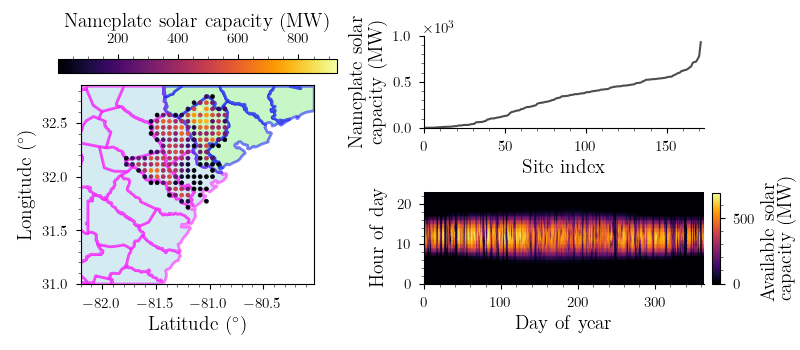

In [47]:
geometry = [Point(xy) for xy in zip(srtd_cap_df['Longitude'], srtd_cap_df['Latitude'])]
gdf = GeoDataFrame(srtd_cap_df, geometry=geometry)

geometry2 = [Point(xy) for xy in zip(srtd_cap_df_reduced['Longitude'], srtd_cap_df_reduced['Latitude'])]
gdf_interest = GeoDataFrame(srtd_cap_df_reduced, geometry=geometry2)

fig, axs = subplot_mosaic("aabb;aacc", figsize=(8, 3.5))

axs["a"].spines["right"].set_visible(True)
axs["a"].spines["top"].set_visible(True)
axs["a"].set_xlabel(r"$\mathrm{Latitude}\ (^{\circ})$")

clip_box = (-82.2, 31.0, -80.025, 32.840)

ga_ax = ga.clip(clip_box).plot(ax=axs["a"], zorder=2, lw=2.0, color="lightblue", edgecolor="magenta", alpha=0.5)
sc_ax = sc.clip(clip_box).plot(ax=axs["a"], zorder=2, lw=2.0, color="lightgreen", edgecolor="blue", alpha=0.5)

ax0_out = gdf.plot(column=sorted_df["capacity"], ax=axs["a"], marker='o', cmap="inferno", markersize=8, zorder=4)

axs["a"].set_ylabel(r"$\mathrm{Longitude}\ (^{\circ})$")

axs["a"].set_ylim((31, 32.85))
axs["a"].set_aspect(1)

cbar = fig.colorbar(
    ScalarMappable(Normalize(vmin=sorted_df["capacity"].min(), 
                             vmax=sorted_df["capacity"].max()), 
                   cmap="inferno"), 
    ax=axs["a"],
    orientation="horizontal", label=r"$\textrm{Nameplate solar capacity (MW)}$", 
    ticklocation="top", location="top"
    )

cbar.ax.yaxis.set_ticks_position("left")

# ============= SECOND SUBPLOT =============

axs["b"].plot(arange(len(sorted_df)) + 1, sorted_df["capacity"].to_numpy(), "-")

axs["b"].set_ylabel(r"$\textrm{Nameplate solar}\newline\hspace*{18pt}\textrm{capacity (MW)}$")
axs["b"].set_xlabel(r"$\textrm{Site\ index}$")

axs["b"].set_xlim((0, 173))
axs["b"].set_ylim((0, 1000))

# ============= THIRD SUBPLOT =============

pcolor = axs["c"].pcolormesh(day_mat-1, hr_mat-1, 800*solar_demand, shading="gouraud", cmap="inferno")

axs["c"].set_xlabel(r"$\mathrm{Day\ of\ year}$")
axs["c"].set_ylabel(r"$\mathrm{Hour\ of\ day}$")

# cbar = fig.colorbar(pcolor, ax=axs["c"], label=r"$\textrm{Excess load}\newline\hspace*{8pt}\textrm{demand (MW)}$", fraction=0.03)
cax = fig.add_axes([0.89, 0.19, 0.01, 0.26])
cbar = fig.colorbar(pcolor, cax=cax, label=r"$\textrm{Available solar}\newline\hspace*{16pt}\textrm{capacity (MW)}$", fraction=0.03)


fig.tight_layout()
fig.align_labels()

fig.subplots_adjust(right=0.88)

fig.savefig("../figures/Fig4.pdf", dpi=150)

# Figure 5: Excess emissions reduction potential in the Port of Savannah region

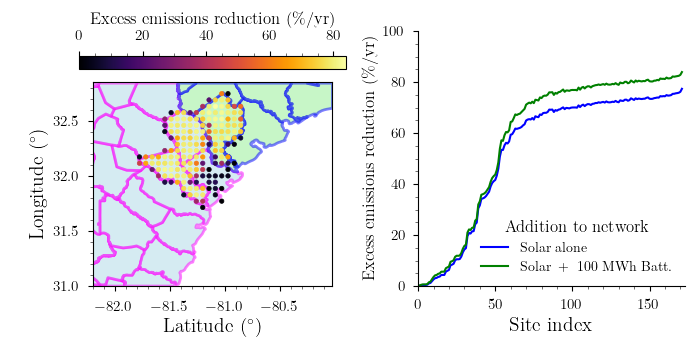

In [48]:
geometry = [Point(xy) for xy in zip(srtd_cap_df_reduced['Longitude'], srtd_cap_df_reduced['Latitude'])]
gdf = GeoDataFrame(srtd_cap_df_reduced, geometry=geometry)

fig, ax = subplots(1, 2, figsize=(7, 3.5))

ax[0].spines["right"].set_visible(True)
ax[0].spines["top"].set_visible(True)
ax[0].set_xlabel(r"$\mathrm{Latitude}\ (^{\circ})$")

clip_box = (-82.2, 31.0, -80.025, 32.840)

ga_ax = ga.clip(clip_box).plot(ax=ax[0], zorder=2, lw=2.0, color="lightblue", edgecolor="magenta", alpha=0.5)
sc_ax = sc.clip(clip_box).plot(ax=ax[0], zorder=2, lw=2.0, color="lightgreen", edgecolor="blue", alpha=0.5)

ax0_out = gdf.plot(column=srtd_cap_df_reduced["carbon_reduction"], ax=ax[0], marker='o', cmap="inferno", markersize=10, zorder=4)

ax[0].set_ylabel(r"$\mathrm{Longitude}\ (^{\circ})$")

ax[0].set_ylim((31, 32.85))
ax[0].set_aspect(1)

cbar = fig.colorbar(
    ScalarMappable(Normalize(vmin=0.0, 
                             vmax=srtd_cap_df_reduced["carbon_reduction"].max()), 
                   cmap="inferno"), 
    ax=ax[0],
    orientation="horizontal", 
    ticklocation="top", location="top"
    )
cbar.set_label(r"$\mathrm{Excess}\ \mathrm{emissions\ reduction\ (\%/yr)}$", fontsize=12)
cbar.ax.yaxis.set_ticks_position("left")

# ============= SECOND SUBPLOT =============

ax[1].plot(arange(tot_red_sites) + 1, carbon_reduction_optimal[sorted_df_reduced_gid, 1, 0], f"b-", zorder=2, label=r"$\mathrm{Solar\ alone}$", ms=4.5)
ax[1].plot(arange(tot_red_sites) + 1, carbon_reduction_optimal[sorted_df_reduced_gid, 1, 1], f"g-", zorder=2, label=r"$\mathrm{Solar\ +\ 100\ MWh\ Batt.}$", ms=4.5)

leg0 = ax[1].legend(
    loc="lower right", 
    prop=dict(size=10), 
    title=r"$\mathrm{Addition\ to\ network}$", 
    title_fontsize=12,
    ncol=1
    )

ax[1].set_ylabel(r"$\textrm{Excess emissions reduction (\%/yr)}$", fontsize=12)
ax[1].set_xlabel(r"$\mathrm{Site\ index}$")

ax[1].set_xlim((0, 173))
ax[1].set_ylim((0, 100))

fig.tight_layout()
fig.align_labels()

fig.savefig("../figures/Fig5.pdf", dpi=150)

# Figure 6: Total electricity cost (TEC) for viable solar sites in the Port of Savannah region.

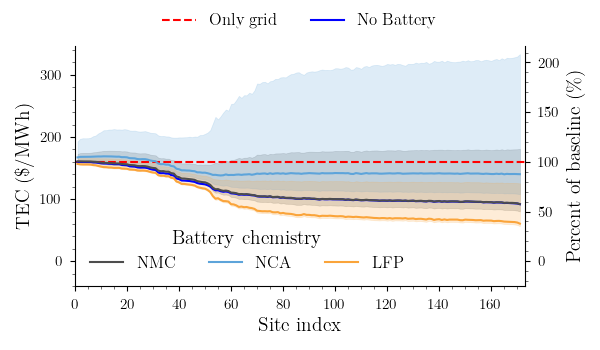

In [49]:
fig, ax = subplots(figsize=(6, 3.5))

ax.axhline(160, ls='--', color='r', zorder=1, label=r"$\mathrm{Only\ grid}$")
ax.plot(arange(171) + 1, cost_no_batt[:,1], "b-", ms=6, label=r"$\mathrm{No\ Battery}$")
ax.plot(arange(171) + 1, cost_w_batt_NMC[:,-1,1,1], "C0-", ms=6, label=r"$\mathrm{NMC}$")
ax.fill_between(arange(171) + 1, cost_w_batt_NMC[:,-1,1,0], cost_w_batt_NMC[:,-1,1,2], color="C0", alpha=0.2, zorder=0)
ax.plot(arange(171) + 1, cost_w_batt_NCA[:,-1,1,1], "C1-", ms=6, label=r"$\mathrm{NCA}$")
ax.fill_between(arange(171) + 1, cost_w_batt_NCA[:,-1,1,0], cost_w_batt_NCA[:,-1,1,2], color="C1", alpha=0.2, zorder=0)
ax.plot(arange(171) + 1, cost_w_batt_LFP[:,-1,1,1], "C2-", ms=6, label=r"$\mathrm{LFP}$")
ax.fill_between(arange(171) + 1, cost_w_batt_LFP[:,-1,1,0], cost_w_batt_LFP[:,-1,1,2], color="C2", alpha=0.2, zorder=0)

handles_og, labels_og = ax.get_legend_handles_labels()
handles1, labels1 = handles_og[:2], labels_og[:2]
handles2, labels2 = handles_og[2:], labels_og[2:]

leg0 = ax.legend(
    handles1, labels1, 
    loc="center", prop=dict(size=12), ncol=2, 
    bbox_to_anchor=(0.5, 1.1), 
    bbox_transform=ax.transAxes
    )

ax.legend(
    handles2, labels2, 
    loc="lower left", prop=dict(size=12), 
    title=r"$\mathrm{Battery\ chemistry}$",
    title_fontsize=14, ncol=3
    )
ax.add_artist(leg0)

ax.set_ylim((-40, None))
ax.set_xlim((0, 173))

ax.set_ylabel(r"$\mathrm{TEC\ (\$/MWh)}$")
ax.set_xlabel(r"$\mathrm{Site\ index}$")

def val2per(x):
    return 1e2*x/160

def per2val(x):
    return (160*x/1e2)

secax = ax.secondary_yaxis('right', functions=(val2per, per2val))
secax.set_ylabel(r'$\mathrm{Percent\ of\ baseline\ (\%)}$')

fig.tight_layout()
fig.align_labels()

fig.subplots_adjust(top=0.87)

fig.savefig("../figures/Fig6.pdf")

# Figure 7:

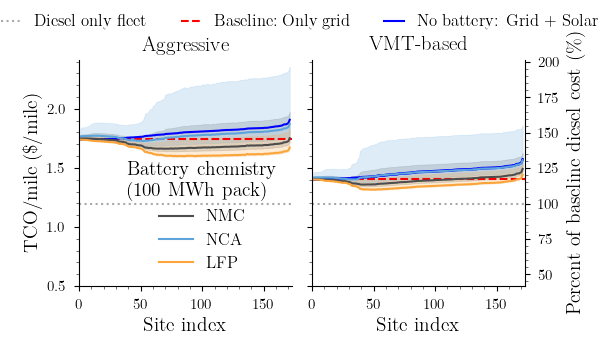

In [50]:
fig, (ax, ax2) = subplots(1, 2, figsize=(6, 3.5), sharex=True, sharey=True)

ax.axhline(TCO_diesel_dayCab_fleet_noDER_perMile, label=r"$\textrm{Diesel only fleet}$", **ref_kwargs)
ax2.axhline(TCO_diesel_dayCab_fleet_noDER_perMile, **ref_kwargs)
ax.axhline(TCO_dayCab_fleet_noDER_perMile, ls="--", color="r", zorder=1, label=r"$\textrm{Baseline:\ Only\ grid}$")

ax.plot(arange(171) + 1, TCO_dayCab_fleet_noBatt_perMile[:,-1,1,-1], "b-", ms=6, label=r"$\textrm{No battery: Grid\ +\ Solar}$")

ax.plot(arange(171) + 1, TCO_dayCab_fleet_wBatt_NMC_perMile[:,-1,1,1], "C0-", ms=6, label=r"$\textrm{NMC}$")
ax.fill_between(arange(171) + 1, TCO_dayCab_fleet_wBatt_NMC_perMile[:,-1,1,0], TCO_dayCab_fleet_wBatt_NMC_perMile[:,-1,1,2], alpha=0.2, color="C0", zorder=0)
ax.plot(arange(171) + 1, TCO_dayCab_fleet_wBatt_NCA_perMile[:,-1,1,1], "C1-", ms=6, label=r"$\textrm{NCA}$")
ax.fill_between(arange(171) + 1, TCO_dayCab_fleet_wBatt_NCA_perMile[:,-1,1,0], TCO_dayCab_fleet_wBatt_NCA_perMile[:,-1,1,2], alpha=0.2, color="C1", zorder=0)
ax.plot(arange(171) + 1, TCO_dayCab_fleet_wBatt_LFP_perMile[:,-1,1,1], "C2-", ms=6, label=r"$\textrm{LFP}$")
ax.fill_between(arange(171) + 1, TCO_dayCab_fleet_wBatt_LFP_perMile[:,-1,1,0], TCO_dayCab_fleet_wBatt_LFP_perMile[:,-1,1,2], alpha=0.2, color="C2", zorder=0)

ax2.axhline(TCO_dayCab_fleet_noDER_perMile2, ls="--", color="r", zorder=1, label=r"$\textrm{Baseline:\ Only\ grid}$")

ax2.plot(arange(171) + 1, TCO_dayCab_fleet_noBatt_perMile2[:,-1,1], "b-", ms=6, label=r"$\textrm{No battery: Grid\ +\ Solar}$")

ax2.plot(arange(171) + 1, TCO_dayCab_fleet_wBatt_NMC_perMile2[:,-1,1,1], "C0-", ms=6, label=r"$\textrm{NMC}$")
ax2.fill_between(arange(171) + 1, TCO_dayCab_fleet_wBatt_NMC_perMile2[:,-1,1,0], TCO_dayCab_fleet_wBatt_NMC_perMile2[:,-1,1,2], alpha=0.2, color="C0", zorder=0)
ax2.plot(arange(171) + 1, TCO_dayCab_fleet_wBatt_NCA_perMile2[:,-1,1,1], "C1-", ms=6, label=r"$\textrm{NCA}$")
ax2.fill_between(arange(171) + 1, TCO_dayCab_fleet_wBatt_NCA_perMile2[:,-1,1,0], TCO_dayCab_fleet_wBatt_NCA_perMile2[:,-1,1,2], alpha=0.2, color="C1", zorder=0)
ax2.plot(arange(171) + 1, TCO_dayCab_fleet_wBatt_LFP_perMile2[:,-1,1,1], "C2-", ms=6, label=r"$\textrm{LFP}$")
ax2.fill_between(arange(171) + 1, TCO_dayCab_fleet_wBatt_LFP_perMile2[:,-1,1,0], TCO_dayCab_fleet_wBatt_LFP_perMile2[:,-1,1,2], alpha=0.2, color="C2", zorder=0)

def val2per(x):
    return 1e2*x/TCO_diesel_dayCab_fleet_noDER_perMile

def per2val(x):
    return (TCO_diesel_dayCab_fleet_noDER_perMile*x/1e2)

secax = ax2.secondary_yaxis('right', functions=(val2per, per2val))
secax.set_ylabel(r'$\mathrm{Percent\ of\ baseline\ diesel\ cost\ (\%)}$')

ax.set_ylabel(r"$\textrm{TCO/mile (\$/mile)}$")
ax.set_title(r"$\textrm{Aggressive}$")
ax2.set_title(r"$\textrm{VMT-based}$")

handles_og, labels_og = ax.get_legend_handles_labels()
handles1, labels1 = handles_og[:3], labels_og[:3]
handles2, labels2 = handles_og[3:], labels_og[3:]

leg0 = fig.legend(
    handles1, labels1, 
    loc="upper center", prop=dict(size=12), ncol=3, 
    bbox_to_anchor=(0.5, 1.0), handlelength=1.2,
    bbox_transform=fig.transFigure
    )

ax.legend(
    handles2, labels2, 
    loc="lower right", prop=dict(size=12), 
    title=r"$\mathrm{Battery\ chemistry}$" + "\n" + r"$\mathrm{(100\ MWh\ pack)}$",
    title_fontsize=14, ncol=1
    )

ax.set_xlabel(r"$\mathrm{Site\ index}$")
ax2.set_xlabel(r"$\mathrm{Site\ index}$")

ax.set_xlim((0, 173))
ax2.set_xlim((0, 173))

ax.set_ylim((0.5, None))
ax2.set_ylim((0.5, None))

fig.tight_layout()
fig.align_labels()

fig.subplots_adjust(top=0.83)

fig.savefig("../figures/Fig7.pdf")

Cost at minimum for LFP for the aggressive electrification scenario

In [51]:
TCO_dayCab_fleet_wBatt_LFP_perMile[:,-1,1,1].min().item()

1.599502638445313

Relative difference between cost at minimum site for aggressive electrification scenario relative to fully diesel-based fleet

In [52]:
(TCO_dayCab_fleet_wBatt_LFP_perMile[:,-1,1,1].min()/TCO_diesel_dayCab_fleet_noDER_perMile).item() - 1

0.33501865776201956

Cost at minimum site for LFP for the VMT-based electrification scenario

In [53]:
TCO_dayCab_fleet_wBatt_LFP_perMile2[:,-1,1,1].min().item()

1.3158045773688714

Relative difference between cost at minimum site for VMT-based electrification scenario relative to fully diesel-based fleet

In [54]:
(TCO_dayCab_fleet_wBatt_LFP_perMile2[:,-1,1,1].min()/TCO_diesel_dayCab_fleet_noDER_perMile).item() - 1

0.09823117420019867

Relative difference between cost at minimum site for aggressive electrification scenario when DERs are deployed relative to when no DERs are deployed

In [55]:
1 - (TCO_dayCab_fleet_wBatt_LFP_perMile[:,-1,1,1].min()/TCO_dayCab_fleet_noDER_perMile).item()

0.08464701520657347

Relative difference between cost at minimum site for VMT-based electrification scenario when DERs are deployed relative to when no DERs are deployed

In [56]:
1 - (TCO_dayCab_fleet_wBatt_LFP_perMile2[:,-1,1,1].min()/TCO_dayCab_fleet_noDER_perMile2).item()

0.06467761542953465

# Figure S26: Recouped TCO in 5-year time frame per kg of CO2 removed

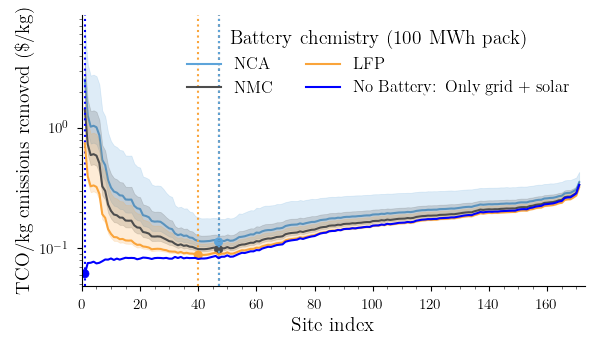

In [57]:
fig, ax = subplots(1, 1, figsize=(6, 3.5), sharex=True, sharey=True)

ax.plot(arange(171) + 1, TCO_utility_wBatt_NCA_perKgCO2[:,-1, 1, 1], "C1-", ms=6, label=r"$\textrm{NCA}$", zorder=0) #2
ax.fill_between(arange(171) + 1, TCO_utility_wBatt_NCA_perKgCO2[:,-1, 1, 0], TCO_utility_wBatt_NCA_perKgCO2[:,-1, 1, 2], alpha=0.2, color="C1", zorder=0) 
ax.plot(arange(171) + 1, TCO_utility_wBatt_NMC_perKgCO2[:,-1, 1, 1], "C0-", ms=6, label=r"$\textrm{NMC}$", zorder=1) #1 
ax.fill_between(arange(171) + 1, TCO_utility_wBatt_NMC_perKgCO2[:,-1, 1, 0], TCO_utility_wBatt_NMC_perKgCO2[:,-1, 1, 2], alpha=0.2, color="C0", zorder=0)
ax.plot(arange(171) + 1, TCO_utility_wBatt_LFP_perKgCO2[:,-1, 1, 1], "C2-", ms=6, label=r"$\textrm{LFP}$", zorder=2) #3
ax.fill_between(arange(171) + 1, TCO_utility_wBatt_LFP_perKgCO2[:,-1, 1, 0], TCO_utility_wBatt_LFP_perKgCO2[:,-1, 1, 2], alpha=0.2, color="C2", zorder=0)
ax.plot(arange(171) + 1, TCO_utility_noBatt_perKgCO2[:,-1, 1, 1], "b-", ms=6, label=r"$\textrm{No\ Battery: Only grid + solar}$", zorder=3) #0

ax.scatter(min_utility_sites[1] + 1, array([TCO_utility_wBatt_NMC_perKgCO2[min_utility_sites[1, 0].astype(int),-1,1,1], TCO_utility_wBatt_NCA_perKgCO2[min_utility_sites[1, 1].astype(int),-1,1,1], TCO_utility_wBatt_LFP_perKgCO2[min_utility_sites[1, 2].astype(int),-1,1,1], TCO_utility_noBatt_perKgCO2[min_utility_sites[1, 3].astype(int),-1,1,1]]), s=6**2, marker="o", c=["C0", "C1", "C2", "b"])
ax.axvline(min_utility_sites[1, 0]+1, ls=":", color="C0", zorder=1)
ax.axvline(min_utility_sites[1, 1]+1, ls=":", color="C1", zorder=1)
ax.axvline(min_utility_sites[1, 2]+1, ls=":", color="C2", zorder=1)
ax.axvline(min_utility_sites[1, 3]+1, ls=":", color="b", zorder=1)

ax.set_ylabel(r"$\textrm{TCO/kg emissions removed (\$/kg)}$")
ax.set_yscale('log')

ax.legend(
    loc="upper right", prop=dict(size=12), 
    title=r"$\mathrm{Battery\ chemistry\ (100\ MWh\ pack)}$",
    title_fontsize=14, ncol=2
    )

ax.set_xlabel(r"$\mathrm{Site\ index}$")

ax.set_xlim((0, 173))
# ax.set_ylim((5e-2, None))

fig.tight_layout()
fig.align_labels()

# fig.subplots_adjust(top=0.87)
# fig.subplots_adjust(top=0.94)

fig.savefig("../figures/FigS26.pdf")